# LSTM Sentiment Analysis with IMDB Reviews


## Objective
Build and compare BiLSTM and GRU models for sentiment classification on the IMDB Movie Reviews dataset.

### Concepts Covered
- TextVectorization
- Tokenization
- Padding and Truncation
- Embedding Layer
- LSTM
- GRU
- Bidirectional RNNs
- Sequence Learning
- Sentiment Analysis


In [1]:

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.21.0


## Load IMDB Dataset

In [2]:

VOCAB_SIZE = 10000
MAX_LEN = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

X_train = tf.keras.preprocessing.sequence.pad_sequences(
    X_train, maxlen=MAX_LEN, padding='post', truncating='post'
)

X_test = tf.keras.preprocessing.sequence.pad_sequences(
    X_test, maxlen=MAX_LEN, padding='post', truncating='post'
)

print(X_train.shape, X_test.shape)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
(25000, 200) (25000, 200)


## Build Bidirectional LSTM Model

In [3]:

bilstm_model = models.Sequential([
    layers.Embedding(VOCAB_SIZE, 128, input_length=MAX_LEN),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()


/Users/ayeshafaiz/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train BiLSTM Model

In [4]:

history_lstm = bilstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 128s 788ms/step - accuracy: 0.7321 - loss: 0.5043 - val_accuracy: 0.8594 - val_loss: 0.3594
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 159s 891ms/step - accuracy: 0.8902 - loss: 0.2825 - val_accuracy: 0.8696 - val_loss: 0.3246
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 152s 964ms/step - accuracy: 0.9159 - loss: 0.2227 - val_accuracy: 0.8666 - val_loss: 0.3838
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 149s 946ms/step - accuracy: 0.9434 - loss: 0.1567 - val_accuracy: 0.8578 - val_loss: 0.4182
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 141s 896ms/step - accuracy: 0.9521 - loss: 0.1341 - val_accuracy: 0.8516 - val_loss: 0.4344
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 317ms/step - accuracy: 0.9649 - loss: 0.0986 - val_accuracy: 0.8506 - val_loss: 0.4817
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 261ms/step - accuracy: 0.9775 - loss: 0.0668 - val_accuracy: 0.8380 - val_loss: 0.7705
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 263ms/step - accuracy: 0.9725 - lo

## Evaluate BiLSTM

In [5]:

lstm_loss, lstm_acc = bilstm_model.evaluate(X_test, y_test, verbose=0)

print("BiLSTM Test Accuracy:", round(lstm_acc, 4))
print("BiLSTM Test Loss:", round(lstm_loss, 4))


BiLSTM Test Accuracy: 0.8112
BiLSTM Test Loss: 0.8582


## Build GRU Model

In [6]:

gru_model = models.Sequential([
    layers.Embedding(VOCAB_SIZE, 128, input_length=MAX_LEN),
    layers.GRU(64),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train GRU Model

In [8]:

history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 223ms/step - accuracy: 0.9943 - loss: 0.0202 - val_accuracy: 0.8554 - val_loss: 0.8227
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 220ms/step - accuracy: 0.9946 - loss: 0.0196 - val_accuracy: 0.8478 - val_loss: 0.8242
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 201ms/step - accuracy: 0.9933 - loss: 0.0223 - val_accuracy: 0.8568 - val_loss: 0.8590
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 212ms/step - accuracy: 0.9960 - loss: 0.0140 - val_accuracy: 0.8598 - val_loss: 1.0840
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 222ms/step - accuracy: 0.9962 - loss: 0.0134 - val_accuracy: 0.8440 - val_loss: 0.9434
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 217ms/step - accuracy: 0.9965 - loss: 0.0119 - val_accuracy: 0.8522 - val_loss: 1.0014
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 217ms/step - accuracy: 0.9983 - loss: 0.0059 - val_accuracy: 0.8322 - val_loss: 0.9932
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 35s 224ms/step - accuracy: 0.9956 - loss: 0

## Evaluate GRU

In [9]:

gru_loss, gru_acc = gru_model.evaluate(X_test, y_test, verbose=0)

print("GRU Test Accuracy:", round(gru_acc, 4))
print("GRU Test Loss:", round(gru_loss, 4))


GRU Test Accuracy: 0.8312
GRU Test Loss: 1.2282


## Compare LSTM vs GRU

In [10]:

comparison = pd.DataFrame({
    "Model": ["BiLSTM", "GRU"],
    "Accuracy": [lstm_acc, gru_acc],
    "Loss": [lstm_loss, gru_loss]
})

comparison


,Model,Accuracy,Loss
0,BiLSTM,0.81116,0.858231
1,GRU,0.83120,1.228155


## Plot Accuracy Curves

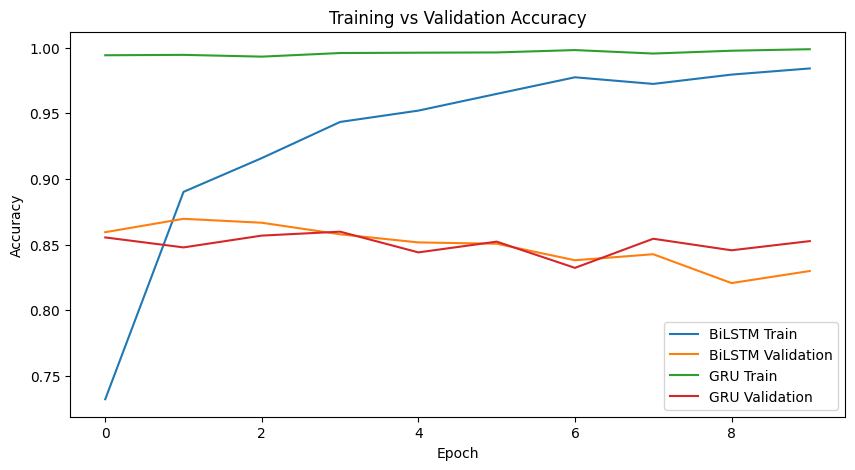

In [11]:

plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['accuracy'], label='BiLSTM Train')
plt.plot(history_lstm.history['val_accuracy'], label='BiLSTM Validation')

plt.plot(history_gru.history['accuracy'], label='GRU Train')
plt.plot(history_gru.history['val_accuracy'], label='GRU Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


## Plot Loss Curves

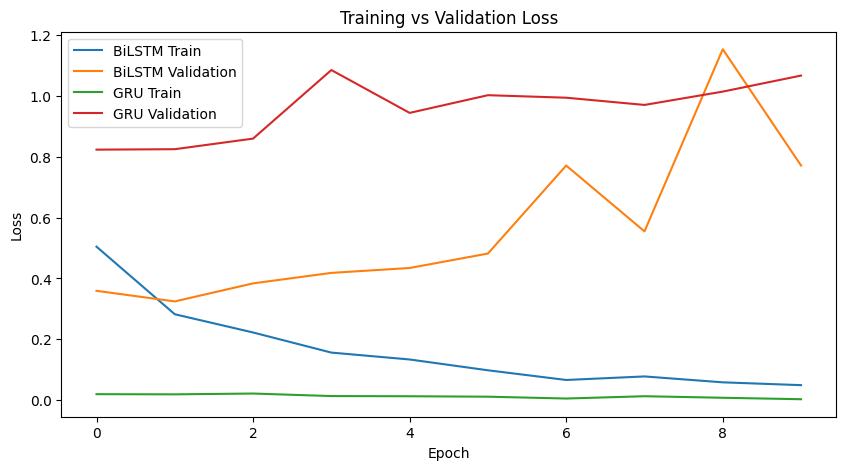

In [12]:

plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'], label='BiLSTM Train')
plt.plot(history_lstm.history['val_loss'], label='BiLSTM Validation')

plt.plot(history_gru.history['loss'], label='GRU Train')
plt.plot(history_gru.history['val_loss'], label='GRU Validation')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


## Display Misclassified Reviews

In [13]:

word_index = imdb.get_word_index()
reverse_word_index = {v + 3: k for k, v in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

preds = bilstm_model.predict(X_test, verbose=0)
pred_labels = (preds > 0.5).astype(int).flatten()

misclassified = np.where(pred_labels != y_test)[0][:5]

for idx in misclassified:
    review = " ".join(
        [reverse_word_index.get(i, "?") for i in X_test[idx] if i != 0]
    )

    print("\nReview Index:", idx)
    print("Actual:", y_test[idx])
    print("Predicted:", pred_labels[idx])
    print(review[:1000])
    print("-"*80)


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Review Index: 5
Actual: 1
Predicted: 0
<START> i'm absolutely disgusted this movie isn't being sold all who love this movie should email disney and increase the demand for it they'd eventually have to sell it then i'd buy copies for everybody i know everything and everybody in this movie did a good job and i haven't figured out why disney hasn't put this movie on dvd or on vhs in rental stores at least i haven't seen any copies this is a wicked good movie and should be seen by all the kids in the new generation don't get to see it and i think they should it should at least be put back on the channel this movie doesn't deserve a cheap <UNK> it deserves the real thing i'm them now this movie will be on dvd
--------------------------------------------------------------------------------

Review Index: 8
Actual: 0
Predicted: 1
<START> hollywood had a long love affair with bogus <UNK> nights tales but few of these products have stood the tes


## Conclusion

- Built an Embedding + Bidirectional LSTM model.
- Built an Embedding + GRU model.
- Compared performance on IMDB reviews.
- Visualized training dynamics.
- Displayed misclassified examples for error analysis.
